## Preprocessing WSI
To visualise images and annotations consider the ASAP software. 
Furthermore, several packages built upon OpenSlide exist to help WSIs management 
via python. For instance, https://github.com/ysbecca/py-wsi. 

### 1. **Setup ambiente**

In [1]:
# 1. Installa i binari di sistema OpenSlide (obbligatorio per far funzionare la libreria Python)
!apt-get update -y && apt-get install -y openslide-tools

# 2. Installa la libreria Python per interfacciarsi a OpenSlide
!pip install openslide-python

# 3. Installa histolab e tiatoolbox (librerie utilissime per il patching automatico e la rimozione dello sfondo)
!pip install histolab tiatoolbox

# 4. Installa patchify (comoda per dividere le immagini in griglie se decidi di fare un approccio manuale)
!pip install patchify

print("\n--- Setup Completato con Successo! ---")

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 https://cli.github.com/packages stable InRelease [3,917 B]               
Get:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]      
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease   
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease    
Get:9 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,297 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,090 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]        
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,959 kB]
Get:13 https://cli.github.com/pa

In [2]:
import openslide # Solo per controllo interno se serve
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

print(f"Versione di OpenSlide rilevata nel sistema: {openslide.__version__}")

Versione di OpenSlide rilevata nel sistema: 1.4.3


In [20]:
import os
import glob


# Definisci i percorsi in base a dove si trova il dataset su Kaggle
# Sostituisci 'nome-del-tuo-dataset' con il nome reale della cartella creata da Kaggle
DATASET_DIR = "../input/datasets/irenebartolini/dataset-two-samples" 

In [18]:
import os

# Questo comando elenca le cartelle principali dentro /input
print("Cartelle disponibili in input:")
print(os.listdir("../input/datasets/irenebartolini"))

Cartelle disponibili in input:
['dataset-two-samples']


### 2. **Struttura Piramidale**
Una WSI contiene la stessa immagine salvata a diverse risoluzioni (es. 40x, 20x, 10x, 5x, 1.25x). Il primo obiettivo è caricare l'immagine e leggerne le proprietà.

In [25]:

import openslide
import os

file_he_to_extract = DATASET_DIR + "/test_2_img/TO26.1_261785_M.58Y_APA-MAPN-MAPM_WS0.__1A.ADR.H-E_.ndpi" 
file_cyp_to_extract = DATASET_DIR + "/test_2_img/TO26.1_261785_M.58Y_APA-MAPN-MAPM_WS0.__1B.ADR.CYP11B2_.ndpi"

if os.path.exists(file_he_to_extract):
    slide_he = openslide.OpenSlide(file_he_to_extract)
    
    print(f"--- Informazioni File H&E ---")
    print(f"Dimensioni totali (Livello 0): {slide_he.dimensions}")
    print(f"Numero di livelli piramidali: {slide_he.level_count}")
    
    # Stampa le dimensioni di ciascun livello e il relativo fattore di rimpicciolimento
    for i in range(slide_he.level_count):
        print(f"Livello {i} -> Dimensioni: {slide_he.level_dimensions[i]} | Downsample: {slide_he.level_downsamples[i]}")


else:
    print(f"File non trovato al percorso: {file_he_to_extract}")
    
if os.path.exists(file_cyp_to_extract):
    slide_cyp = openslide.OpenSlide(file_cyp_to_extract)
    
    print(f"--- Informazioni File CYP ---")
    print(f"Dimensioni totali (Livello 0): {slide_cyp.dimensions}")
    print(f"Numero di livelli piramidali: {slide_cyp.level_count}")
    
    # Stampa le dimensioni di ciascun livello e il relativo fattore di rimpicciolimento
    for i in range(slide_cyp.level_count):
        print(f"Livello {i} -> Dimensioni: {slide_cyp.level_dimensions[i]} | Downsample: {slide_cyp.level_downsamples[i]}")


else:
    print(f"File non trovato al percorso: {file_cyp_to_extract}")


--- Informazioni File H&E ---
Dimensioni totali (Livello 0): (145920, 92928)
Numero di livelli piramidali: 9
Livello 0 -> Dimensioni: (145920, 92928) | Downsample: 1.0
Livello 1 -> Dimensioni: (72960, 46464) | Downsample: 2.0
Livello 2 -> Dimensioni: (36480, 23232) | Downsample: 4.0
Livello 3 -> Dimensioni: (18240, 11616) | Downsample: 8.0
Livello 4 -> Dimensioni: (9120, 5808) | Downsample: 16.0
Livello 5 -> Dimensioni: (4560, 2904) | Downsample: 32.0
Livello 6 -> Dimensioni: (2280, 1452) | Downsample: 64.0
Livello 7 -> Dimensioni: (1140, 726) | Downsample: 128.0
Livello 8 -> Dimensioni: (570, 363) | Downsample: 256.0
--- Informazioni File CYP ---
Dimensioni totali (Livello 0): (107520, 92928)
Numero di livelli piramidali: 9
Livello 0 -> Dimensioni: (107520, 92928) | Downsample: 1.0
Livello 1 -> Dimensioni: (53760, 46464) | Downsample: 2.0
Livello 2 -> Dimensioni: (26880, 23232) | Downsample: 4.0
Livello 3 -> Dimensioni: (13440, 11616) | Downsample: 8.0
Livello 4 -> Dimensioni: (6720, 

*Spiegazione*
- **Dimensioni totali (Livello 0): (145920, 92928)**
Questo è il livello alla massima risoluzione possibile (lo zoom massimo del microscopio, di solito 20x o 40x).Significa che l'immagine è larga $145.920$ pixel e alta $92.928$ pixel.Se provassi a calcolare i megapixel totali: $145.920 \times 92.928 = 13.559.051.520$ pixel (ovvero circa 13,5 Gigapixel / 13 miliardi di pixel!).

Nel progetto: Questo è il livello su cui dovrai estrarre i patch per addestrare il tuo modello di Machine Learning (U-Net o Feature Extractor), perché contiene i dettagli cellulari necessari per distinguere il tessuto.

- **Numero di livelli piramidali: 9**
Lo scanner ha salvato 9 "versioni" della stessa identica immagine dentro lo stesso file, contrassegnate da un indice che va da 0 a 8.

- **Downsample**:
Il valore di Downsample indica di quante volte l'immagine è stata rimpicciolita rispetto al Livello 0 originale.

Livello 0 (Downsample: 1.0): È l'immagine originale a grandezza naturale.
Livello 2 (Downsample: 4.0): L'immagine è 4 volte più piccola del Livello 0. 

Infatti, se prendi la larghezza originale ($145920$) e la dividi per 4, ottieni esattamente $36480$.Livello 8 (Downsample: 256.0): È la punta della piramide. L'immagine è stata rimpicciolita di 256 volte. Ha una dimensione minuscola ($570 \times 363$ pixel), simile a una normale foto scattata con un vecchio telefono.

### 3. **Visualizzare una "Thumbnail" (Anteprima)**
Dato che l'immagine al Livello 0 è troppo grande per la memoria RAM, per visualizzarla interamente estrarre l'ultimo livello (a minor risoluzione).

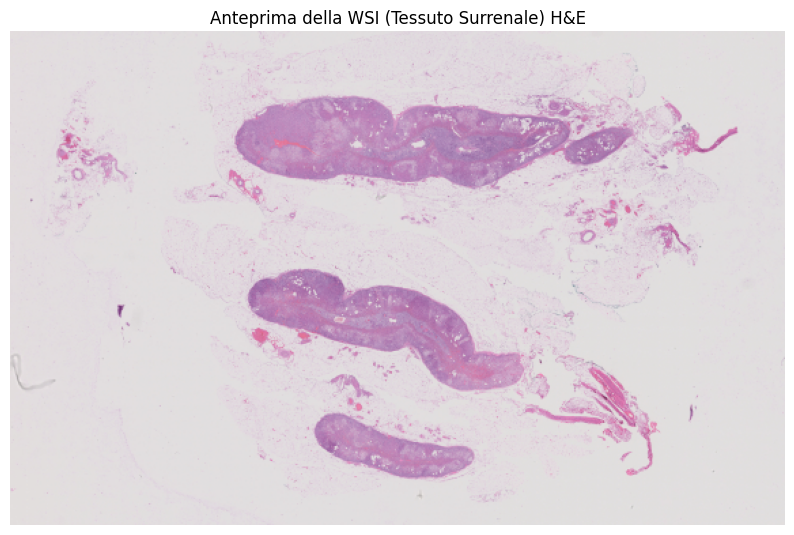

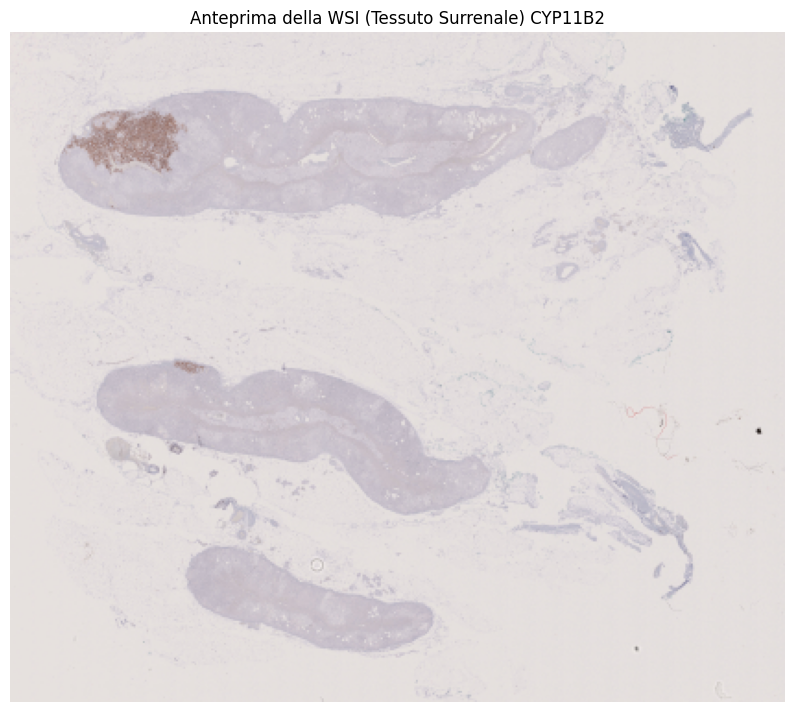

In [26]:
import matplotlib.pyplot as plt

# Estrai una miniatura (thumbnail) specificando la larghezza massima desiderata
thumbnail_he = slide_he.get_thumbnail(size=(570, 363))
thumbnail_cyp = slide_cyp.get_thumbnail(size=(420, 363))


# Mostrala a schermo
plt.figure(figsize=(10, 10))
plt.imshow(thumbnail_he)
plt.title("Anteprima della WSI (Tessuto Surrenale) H&E")
plt.axis('off')
plt.show()

plt.figure(figsize=(10, 10))
plt.imshow(thumbnail_cyp)
plt.title("Anteprima della WSI (Tessuto Surrenale) CYP11B2")
plt.axis('off')
plt.show()

### 4. **Rilevamento del Tessuto (Tissue Masking)**
Le WSI contengono moltissimo "spazio bianco" (il vuoto intorno al pezzetto di tessuto sul vetrino). Elaborare i patch bianchi è uno spreco di tempo e risorse computazionali. E' necessario creare una maschera che identifichi solo il tessuto.

Converto l'anteprima in scala di grigi o nello spazio colore HSV e applicando una soglia (Otsu Thresholding):

In [ ]:
# import cv2
# import numpy as np

# # Converti la miniatura in array numpy
# img_np = np.array(thumbnail)

# # Passa a scala di grigi e applica un filtro Gaussiano per ridurre il rumore
# gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
# blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# # Soglia di Otsu per separare tessuto (scuro) dallo sfondo (bianco brillante)
# _, tissue_mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# # Visualizza il risultato
# plt.imshow(tissue_mask, cmap='gray')
# plt.title("Maschera del Tessuto (In bianco le aree da analizzare)")
# plt.show()

# 5. **Logica del Patching**
Una volta isolato il tessuto, estrarre i patch alla massima risoluzione (Livello 0) solo dalle zone in cui la maschera è positiva. Scegliamo la dimensione del patch (es. $256 \times 256$ o $512 \times 512$ pixel). 


**NOTA**: Le WSI occupano tantissimo spazio.  l'ambiente Kaggle ha un limite di spazio sul disco locale (20GB per l'output).

**Non salvare i patch come singole immagini** .png o .jpg sul disco di Kaggle, per non esaurire la memoria (Disk quota exceeded).

Strategia migliore: **Estrai i patch "al volo" (on-the-fly) mentre addestri il modello usando un Dataset custom di PyTorch**.

In [ ]:
# Esempio per estrarre un singolo patch a coordinate specifiche
# x_coord = 5000  # Coordinate riferite sempre al livello 0 (massima risoluzione)
# y_coord = 8000
# patch_size = (256, 256)
# target_level = 0

# # Leggi la regione
# patch = slide.read_region((x_coord, y_coord), target_level, patch_size)
# # Nota: read_region restituisce un'immagine RGBA, convertila in RGB
# patch = patch.convert("RGB")

# plt.imshow(patch)
# plt.axis('off')
# plt.show()